# 2D Convection-Diffusion Numerical Simulation Visulization

In this notebook, we will explore and compare the results of the 2D numerical simulazation, and eventually visuliza the results.

## Test Run

In the following section, the 2D advection-diffusion model was run and visualized just for example. The actual error analysis and sensitivity test is in the next a few sections.

In [14]:
import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
# import the pde solver for a simple 1-d tank of water with a drop of rain
import adv_dif_2D_arr
import adv_dif_2D_arr_Nflux
import adv_dif_2D_bott
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar
# import the PDE solver for 2D advection-diffusion problem
import adv_dif_2D_arr
import adv_dif_2D_arr_Nflux

In [15]:
# set parameters
Lx=50
Ly=50
T=1000
n_x = 100
n_y = 100
n_time = 1000
dx = Lx / (n_x-1)
dy = Ly / (n_y-1)
dt = T / (n_time-1)
x = np.linspace(0,Lx,n_x)
y = np.linspace(0,Ly,n_y)
t = np.linspace(0,T,n_time)
U = 0 # 0 for constant wind / 1 for y-dependent wind 
N_flux = 0.01 # only for adv_dif_2D_Nflux (default=0.01 per time)

In [16]:
# load and use the PDE solver
importlib.reload(adv_dif_2D_arr)
importlib.reload(adv_dif_2D_arr_Nflux)

c=adv_dif_2D_arr.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U])
#c=adv_dif_2D_arr_Nflux.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U, N_flux])

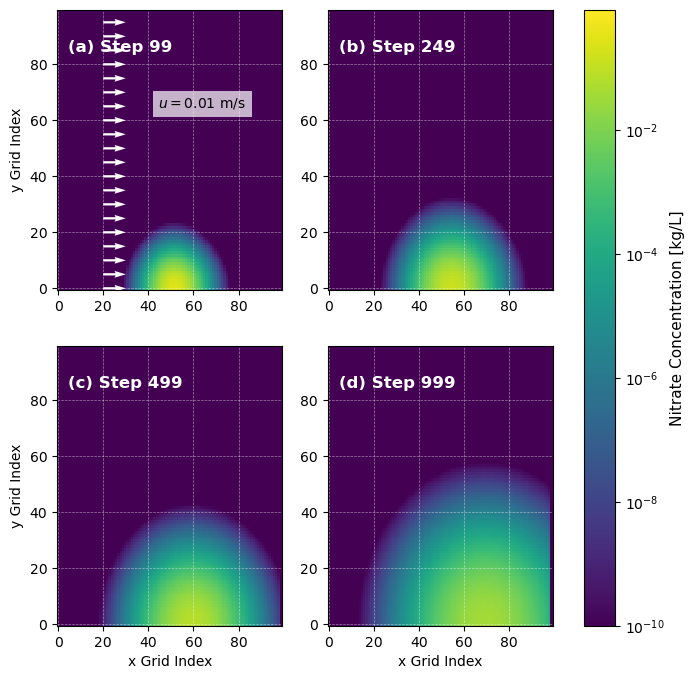

In [22]:
# 2D Visulization

import matplotlib.colors as mcolors

# print(np.shape(c))
# The size would be (100, 100, 1000)

x = np.arange(100)
y = np.arange(100)
X1, Y1 = np.meshgrid(x, y)

minval = np.min(c[:,:,:])
maxval = np.max(c[:,:,:])

# print(minval,maxval)

cmap = cmx.viridis
norm = mcolors.LogNorm(vmin=1e-10, vmax=maxval)

fig,axes = plt.subplots(2,2,figsize=(8,8))

tt =[99,249,499,999]
labels = ['(a)', '(b)', '(c)', '(d)']


# cc=cc.swapaxes(0,1)

for ax in axes.flatten():
    t=tt.pop(0)
    cc=c[t,:,:]
    # Prevent 0 by adding a small number
    cc=cc+1e-11
    label=labels.pop(0)

    # Show grid
    # ax.axis('off')
    ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)

    im = ax.pcolor(X1, Y1, cc.T, cmap=cmap, norm=norm, shading='nearest')
    label_full = label + ' Step %d' %t
    ax.text(0.05, 0.85, label_full,  transform=ax.transAxes, color='white', fontsize=12, fontweight='bold')
    
    if label == '(c)' or label =='(d)':
        ax.set_xlabel('x Grid Index')
    if label == '(a)' or label =='(c)':
        ax.set_ylabel('y Grid Index')
        

Y_arrow_position = 20
X_arrow = x[::5]
Y_arrow = np.zeros(np.shape(X_arrow)) + Y_arrow_position

V_speed = np.ones(np.shape(X_arrow))
U_speed = np.zeros(np.shape(X_arrow))

# Water speed arrow
axes[0, 0].quiver(Y_arrow, X_arrow, V_speed,U_speed, color='white', scale=10, width=0.01, zorder=3)
axes[0, 0].text(0.45, 0.65, '$u=0.01$ m/s', transform=axes[0, 0].transAxes, color='black', 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Add colorbar
cbar = fig.colorbar(im, ax=axes)
cbar.set_label('Nitrate Concentration [kg/L]', fontsize=11)

plt.show()

With subplots of different time functional, it would be great to start animate the 2D model.

In [ ]:
# Animation
# see link:https://matplotlib.org/stable/gallery/animation/simple_scatter.html for guideline
# to generate gif

import matplotlib.animation as animation
from IPython.display import HTML

fig,ax = plt.subplots(1,1,figsize=(6,6))

ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)

# Initial fig: t0

t0=0
cc0=c[:,:,t0]
cc0=cc0+1e-11

im = ax.pcolor(X1, Y1, cc0, cmap=cmap, norm=norm, shading='nearest')
label= ' Step %d' %t0
ax.text(0.05, 0.05, label,  transform=ax.transAxes, color='white', fontsize=12, fontweight='bold')

# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Nitrate Concentration [kg/L]', fontsize=11)

# Add arrows
ax.quiver(X_arrow, Y_arrow, U_speed, V_speed, color='white', scale=10, width=0.01, zorder=3)
# Add text to demonstrate the current speed
time_text = ax.text(0.7, 0.15, '$u=0.01$m/s',  transform=ax.transAxes, color='white', fontsize=10)
    
plt.tight_layout()

# Function that renews the plot
def plot_renew(tt):
    cc=c[:,:,tt]+1e-11
    im.set_array(cc.ravel())

    # Renew time label
    time_text.set_text(f' Step {tt}')

    return im, time_text

time_series=range(0,1000,10)
ani = animation.FuncAnimation(fig, plot_renew, frames=time_series, interval=50, blit=True)

plt.close(fig)
HTML(ani.to_jshtml())
# Save animation
ani.save('wave_animation.gif', writer='pillow', fps=20)

When 2D one_time_input is ready, the following section will generate nitrate concentration variation over time.

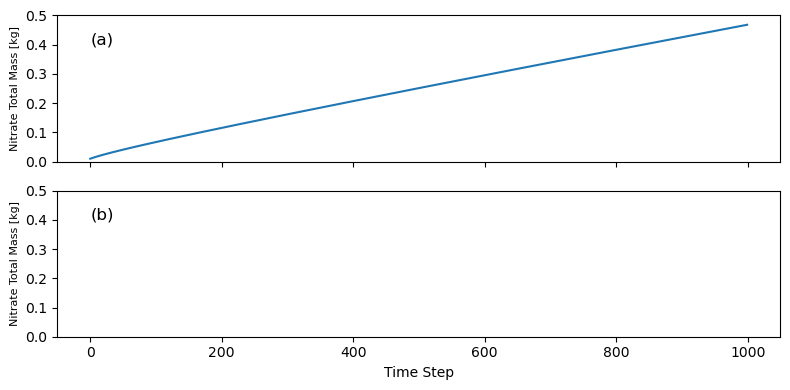

In [88]:
# Total mass over time in the system (to see if it's conserved)
# in so far, we have increasing value of total nitrate only. 
# other sccenerios will be attached as soon as the codes are ready.
total_mass=np.sum(c,axis=(0,1))

fig,axes = plt.subplots(2,1,figsize=(8,4),sharex=True)

# print(np.shape(total_mass))

# total time
time_array=range(1000)

# labels
labels = ['(a)', '(b)', '(c)', '(d)']


axes[0].plot(time_array,total_mass)
axes[0].set_ylim([0,0.5])
# Add labels 
axes[0].set_ylabel('Nitrate Total Mass [kg]',fontsize=8)


axes[1].set_ylabel('Nitrate Total Mass [kg]',fontsize=8)

axes[1].set_xlabel('Time Step')
axes[1].set_ylim([0,0.5])

# Penal
axes[0].text(0.1, 0.4, labels[0], fontsize=12)
axes[1].text(0.1, 0.4, labels[1], fontsize=12)

plt.tight_layout()


plt.show()

## 2D Model Description

The notes to run different models were documented in this section.



### Model Difference

In *adv_dif_2D_arr.py*, forward Euler scheme was implemented to run adv-dif simulation, while in *adv_dif_2D_bott.py*, Bott scheme was used. *Nflux* means constant release of nitrate, while functions without *Nflux* used one-time release of nitrate.

Note that initial conditions were totally different from analytical and numerical solutions as the release of numerical solutions are defined as releasing in a field, instead of at one specific point.

### How to Run

The following parameter were needed to run the different models.

In [4]:
# Import

import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar
# import the PDE solver for 2D advection-diffusion problem
import adv_dif_2D_bott
import adv_dif_2D_bott_Nflux


import adv_dif_2D_arr
import adv_dif_2D_arr_Nflux


******************************
context imported. Front of path:
/Users/qiujunqi/Desktop/文件/课程/25秋冬/EOSC 511
back of path: /Users/qiujunqi/MOAD/tools/SalishSeaTools
******************************

through /Users/qiujunqi/Desktop/文件/课程/25秋冬/EOSC 511/EOSC511-TheDeepThinkers/2D visulization/context.py


In [5]:
# set parameters
Lx=50
Ly=50
T=1000
n_x = 100
n_y = 100
n_time = 1000
dx = Lx / (n_x-1)
dy = Ly / (n_y-1)
dt = T / (n_time-1)
x = np.linspace(0,Lx,n_x)
y = np.linspace(0,Ly,n_y)
t = np.linspace(0,T,n_time)
U = 0 # 0 for constant wind / 1 for y-dependent wind 
N_flux = 0.01 # only for adv_dif_2D_Nflux (default=0.01 per time)

in which, U represented the different sets of flow field, N-flux represented the influx of nitrate over time. The functions were called in the following codes.

In [ ]:
# c=adv_dif_2D_arr.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U])

# c=adv_dif_2D_arr_Nflux.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U, N_flux])

## Error Analysis

The function to calculate nitrate concentration based on analytical solution (see *2D Analytical Solution.ipynb*) was first defined, and models using different schemes were compared against analytical solution.

In [6]:
def adv_dif_2D_analytical(Parameters_Error_Analysis):
    """
    Analytical solution for 2D advection-diffusion function. Inputs and outputs are identical (basically) with dv_dif_2D_arr.
    """
    n_x = int(Parameters_Error_Analysis[0])
    n_y = int(Parameters_Error_Analysis[1])
    n_time = int(Parameters_Error_Analysis[2])
    Lx = int(Parameters_Error_Analysis[3])
    Ly = int(Parameters_Error_Analysis[4])
    T = int(Parameters_Error_Analysis[5])
    
    # U = int(Parameters_Error_Analysis[6]) Useless, because analytical solution has no changing flow velocity.

    # Physical parameters for analytical solution
    D = 0.01
    v0 = 0.01
    dx = Lx / (n_x - 1)
    dy = Ly / (n_y - 1)
    c0_val = 1     # Initial release was determined by the final total concentration
    
    # Grids
    x = np.linspace(0, Lx, n_x)
    y = np.linspace(0, Ly, n_y)
    t = np.linspace(0, T, n_time)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    # Initial concentration
    c_vals = np.zeros((n_time, n_x, n_y))
    
    # Release center
    x_center = x[n_x // 2]
    y_center = y[1]
    c_vals[0, n_x // 2, 0] = c0_val
    
    # Start calculating
    for ts in range(1, n_time):
        cur_t = t[ts]
        
        
        # c(x,t) = (2*c0) / (4*pi*D*t) * exp( -((x-xc-v0*t)^2 + (y-yc)^2) / (4*D*t) )
        coef = (2 * c0_val) / (4 * np.pi * D * cur_t)
        exponent = -((X - x_center - v0 * cur_t)**2 + (Y - y_center )**2) / (4 * D * cur_t)
        
        c_vals[ts, :, :] = coef * np.exp(exponent)
        
    return c_vals

### Analytical Solution Visualization

In [7]:
# Analytical Shape

c_analytical=adv_dif_2D_analytical([n_x, n_y, n_time, Lx, Ly, T, U])

print(np.shape(c_analytical))


(1000, 100, 100)


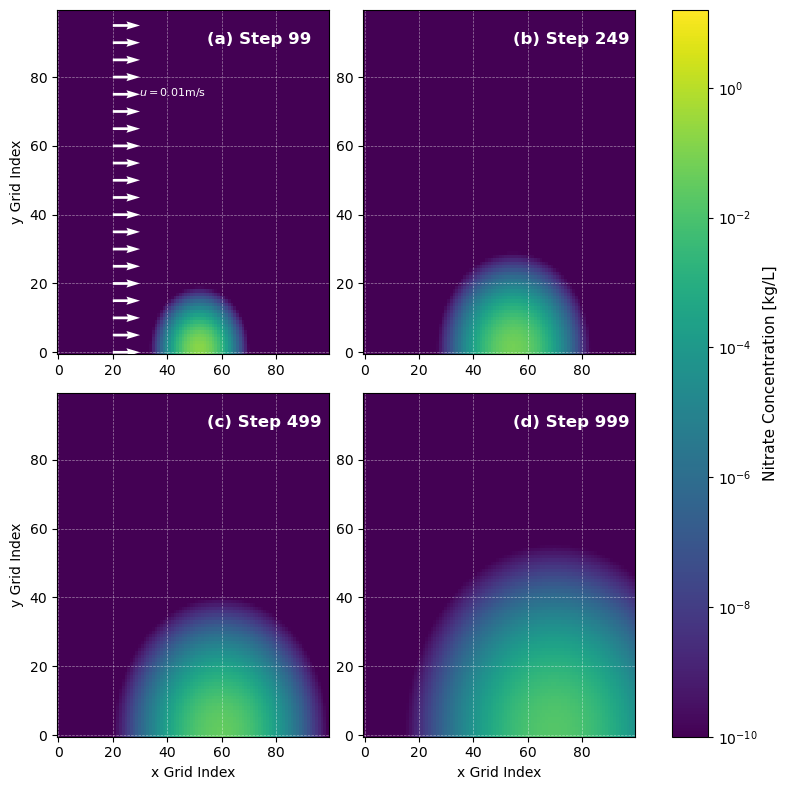

In [16]:
# Analytical Visualization

x = np.arange(100)
y = np.arange(100)
X1, Y1 = np.meshgrid(x, y)

minval = np.min(c_analytical[:,:,:])
maxval = np.max(c_analytical[:,:,:])

# print(minval,maxval)

cmap = cmx.viridis
norm = colors.LogNorm(vmin=1e-10, vmax=maxval)

fig,axes = plt.subplots(2,2,figsize=(8,8))

tt =[99,249,499,999]
labels = ['(a)', '(b)', '(c)', '(d)']


# cc=cc.swapaxes(0,1)

for ax in axes.flatten():
    t=tt.pop(0)
    cc=c_analytical[t,:,:]
    # Prevent 0 by adding a small number
    cc=cc+1e-11
    label=labels.pop(0)

    # Show grid
    # ax.axis('off')
    ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)

    im = ax.pcolor(X1, Y1, cc.T, cmap=cmap, norm=norm, shading='nearest')
    label_full = label + ' Step %d' %t
    ax.text(0.55, 0.9, label_full,  transform=ax.transAxes, color='white', fontsize=12, fontweight='bold')
    
    if label == '(c)' or label =='(d)':
        ax.set_xlabel('x Grid Index')
    if label == '(a)' or label =='(c)':
        ax.set_ylabel('y Grid Index')
        

# Add quiver to represent flow speed
# Arrow position
X_arrow_position=20
Y_arrow=y[::5]
X_arrow=np.zeros(np.shape(Y_arrow))+X_arrow_position
# Speed distribution
V_speed=np.zeros(np.shape(X_arrow)) # The speed is given from fig: Current Distribution
U_speed=np.ones(np.shape(X_arrow))
# Quiver plot
# The smaller scale is, the bigger arrows are
axes[0,0].quiver(X_arrow, Y_arrow, U_speed, V_speed, color='white', scale=10, width=0.01, zorder=3)

# Add text to demonstrate the current speed
axes[0,0].text(0.3, 0.75, '$u=0.01$m/s',  transform=axes[0,0].transAxes, color='white', fontsize=8)
    

plt.tight_layout()

# Add colorbar
cbar = fig.colorbar(im, ax=axes)
cbar.set_label('Nitrate Concentration [kg/L]', fontsize=11)

plt.show()

Looking good!

### Error Analysis


In [47]:
# arr and bott run

c_arr=adv_dif_2D_arr.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U])
c_bott=adv_dif_2D_bott.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U])

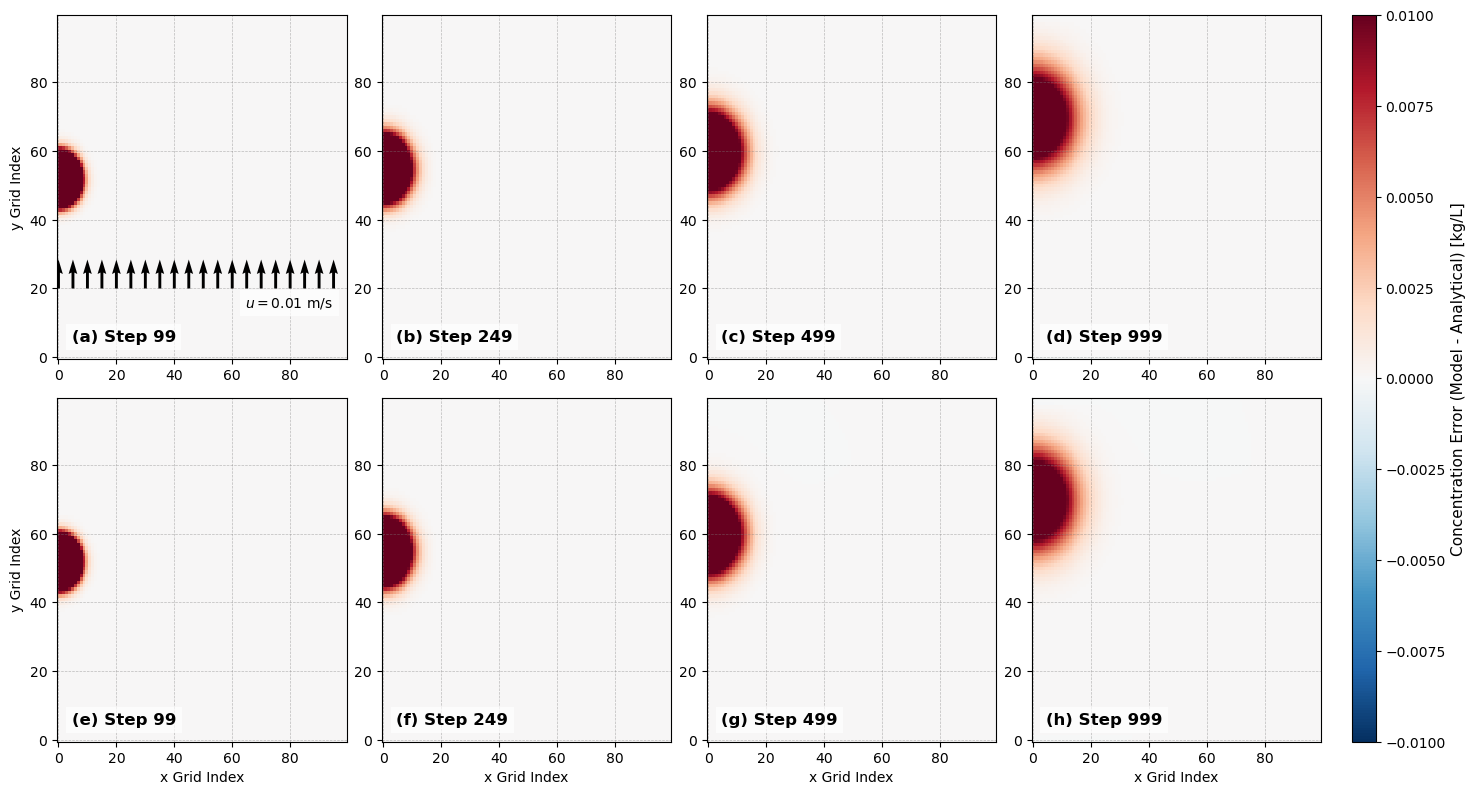

In [70]:
# Error Visualization

c_arr_err=c_arr-c_analytical

c_bott_err=c_bott[:1000, 2:-2, :]-c_analytical

x = np.arange(100)
y = np.arange(100)
X1, Y1 = np.meshgrid(x, y)


# max_err = max(np.max(np.abs(c_arr_err)), np.max(np.abs(c_bott_err)))
max_err = 1e-2

cmap = plt.get_cmap('RdBu_r') 
norm = colors.Normalize(vmin=-max_err, vmax=max_err)


fig, axes = plt.subplots(2, 4, figsize=(16, 8))

tt = [99, 249, 499, 999]
labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)', '(g)', '(h)']


for i in range(2):
    for j in range(4):
        ax = axes[i, j]
        t = tt[j]
        label = labels[i * 4 + j]
        
        # arr first line, bott second line
        if i == 0:
            cc = c_arr_err[t, :, :]
        else:
            cc = c_bott_err[t, :, :]
            
        # 
        ax.grid(True, color='grey', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)

        im = ax.pcolor(X1, Y1, cc, cmap=cmap, norm=norm, shading='nearest')
        
        # Text
        label_full = f"{label} Step {t}"
        ax.text(0.05, 0.05, label_full, transform=ax.transAxes, color='black', 
                fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))
        
        # Label
        if i == 1: 
            ax.set_xlabel('x Grid Index')
        if j == 0: 
            ax.set_ylabel('y Grid Index')


Y_arrow_position = 20
X_arrow = x[::5]
Y_arrow = np.zeros(np.shape(X_arrow)) + Y_arrow_position

V_speed = np.ones(np.shape(X_arrow))
U_speed = np.zeros(np.shape(X_arrow))

# Water speed arrow
axes[0, 0].quiver(X_arrow, Y_arrow, U_speed, V_speed, color='black', scale=10, width=0.01, zorder=3)
axes[0, 0].text(0.65, 0.15, '$u=0.01$ m/s', transform=axes[0, 0].transAxes, color='black', 
                fontsize=10, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

plt.tight_layout()

# Shared colorbar
cbar = fig.colorbar(im, ax=axes.ravel().tolist(), aspect=30, pad=0.02)
cbar.set_label('Concentration Error (Model - Analytical) [kg/L]', fontsize=11)

plt.show()

4.446279888494946 10.69168376172935 10.689275999635324


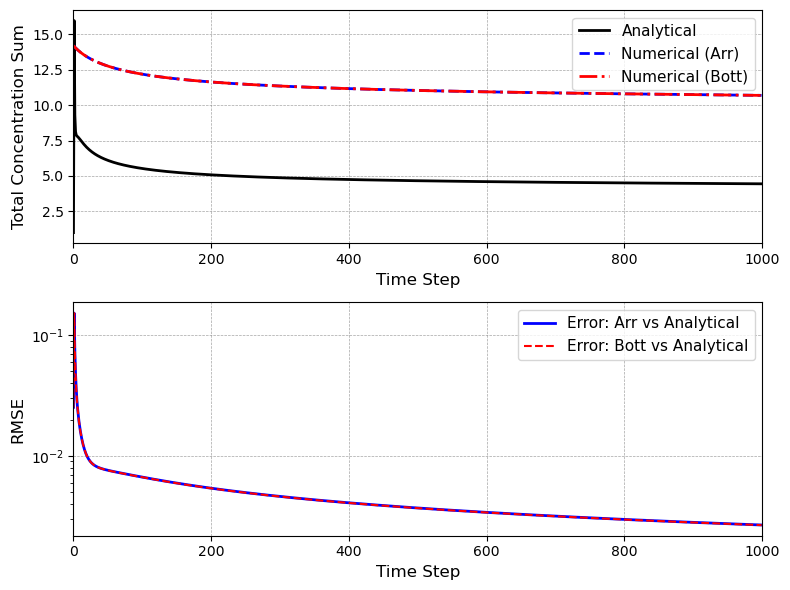

In [72]:
# Error and total concentration vs time

import numpy as np
import matplotlib.pyplot as plt


n_time_steps = c_analytical.shape[0]
time_axis = np.arange(n_time_steps)

# Get rig od ghost grids
c_bott_aligned = c_bott[:n_time_steps, 2:-2, :]

# total concentration
sum_analytical = np.sum(c_analytical, axis=(1, 2))
sum_arr = np.sum(c_arr[:n_time_steps, :, :], axis=(1, 2))
sum_bott = np.sum(c_bott_aligned, axis=(1, 2))

# calculate rmse
rmse_arr = np.sqrt(np.mean((c_arr[:n_time_steps, :, :] - c_analytical)**2, axis=(1, 2)))
rmse_bott = np.sqrt(np.mean((c_bott_aligned - c_analytical)**2, axis=(1, 2)))

# visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# concentration vs time
ax1.plot(time_axis, sum_analytical, label='Analytical', color='black', linewidth=2, linestyle='-')
ax1.plot(time_axis, sum_arr, label='Numerical (Arr)', color='blue', linewidth=2, linestyle='--')
ax1.plot(time_axis, sum_bott, label='Numerical (Bott)', color='red', linewidth=2, linestyle='-.')

# ax1.set_title('Total Concentration vs. Time\n(Check for Mass Conservation)', fontsize=14)
ax1.set_xlabel('Time Step', fontsize=12)
ax1.set_ylabel('Total Concentration Sum', fontsize=12)
ax1.grid(True, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
ax1.legend(fontsize=11)

print(sum_analytical[-1], sum_arr[-1], sum_bott[-1])

# error vs time
ax1.set_xlim([0, n_time_steps])

ax2.plot(time_axis, rmse_arr, label='Error: Arr vs Analytical', color='blue', linewidth=2)
ax2.plot(time_axis, rmse_bott, label='Error: Bott vs Analytical', color='red', linewidth=1.5,linestyle='--')

# ax2.set_title('Root Mean Square Error (RMSE) vs. Time', fontsize=14)
ax2.set_xlabel('Time Step', fontsize=12)
ax2.set_ylabel('RMSE', fontsize=12)
ax2.grid(True, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.legend(fontsize=11)
ax2.set_xlim([0, n_time_steps])


ax2.set_yscale('log')

plt.tight_layout()
plt.show()



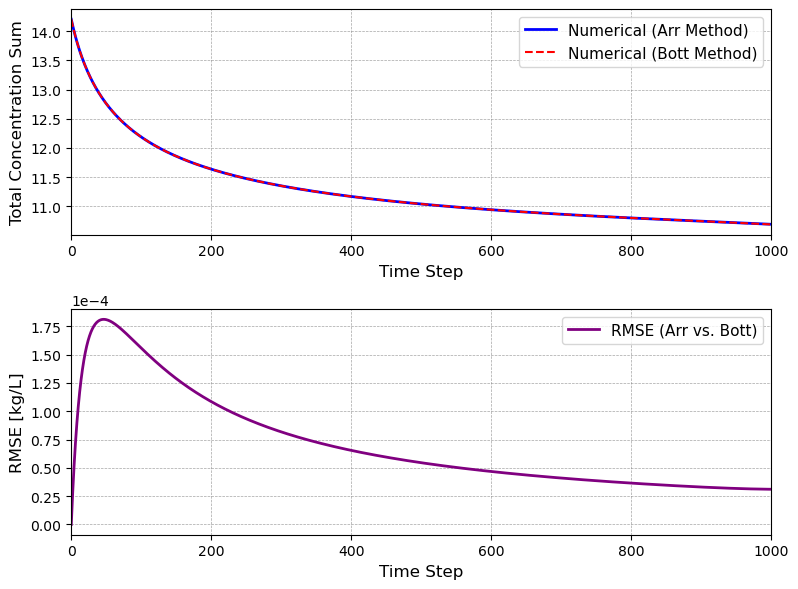

In [65]:
# Error of bott vs arr

import numpy as np
import matplotlib.pyplot as plt



# match time steps
n_time_steps = min(c_arr.shape[0], c_bott.shape[0])

# match space steps
c_arr_aligned = c_arr[:n_time_steps, :, :]
c_bott_aligned = c_bott[:n_time_steps, 2:-2, :]

time_axis = np.arange(n_time_steps)

# concentration vs time
sum_arr = np.sum(c_arr_aligned, axis=(1, 2))
sum_bott = np.sum(c_bott_aligned, axis=(1, 2))

# RMSE: Arr vs Bott
rmse_diff = np.sqrt(np.mean((c_arr_aligned - c_bott_aligned)**2, axis=(1, 2)))


# visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Total contration vs time: NOT conservative
ax1.plot(time_axis, sum_arr, label='Numerical (Arr Method)', color='blue', linewidth=2, linestyle='-')
ax1.plot(time_axis, sum_bott, label='Numerical (Bott Method)', color='red', linewidth=1.5, linestyle='--')

# ax1.set_title('Total Concentration', fontsize=14, fontweight='bold')
ax1.set_xlabel('Time Step', fontsize=12)
ax1.set_ylabel('Total Concentration Sum', fontsize=12)
ax1.grid(True, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
ax1.legend(fontsize=11)
ax1.set_xlim([0, n_time_steps])

# RMSE vs time
ax2.plot(time_axis, rmse_diff, label='RMSE (Arr vs. Bott)', color='purple', linewidth=2)

# ax2.set_title('RMSE', fontsize=14, fontweight='bold')
ax2.set_xlabel('Time Step', fontsize=12)
ax2.set_ylabel('RMSE [kg/L]', fontsize=12)
ax2.grid(True, color='grey', linestyle='--', linewidth=0.5, alpha=0.7)
ax2.legend(fontsize=11)
ax2.set_xlim([0, n_time_steps])


ax2.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

plt.tight_layout()
plt.show()

## Sensitivity Experiment

4 sets of experiments, including baseline, were run based on the *adv_dif_2D_bott_Nflux.py*. The parameters of sensitivity experiment are given by the following table.

| Experiment           | u [m/s] | D [m^2/s] |
|----------------------|---------|-------------|
| Baseline             | 0.01    | 0.01        |
| X Dependent Velocity | 0-0.03  | 0.01        |
| High Velocity        | 0.1       | 0.01        |
| High Diffusion       | 0.01    | 0.02        |

Another experiment of initial release was also conducted.


In [18]:
# Import

import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar
# import the PDE solver for 2D advection-diffusion problem
import adv_dif_2D_bott
import adv_dif_2D_bott_Nflux
import adv_dif_2D_bott_Nflux_High_D
import adv_dif_2D_bott_Nflux_High_u


In [19]:


# set parameters
Lx=50
Ly=50
T=1000
n_x = 100
n_y = 100
n_time = 1000
dx = Lx / (n_x-1)
dy = Ly / (n_y-1)
dt = T / (n_time-1)
x = np.linspace(0,Lx,n_x)
y = np.linspace(0,Ly,n_y)
t = np.linspace(0,T,n_time)
U = 0 # 0 for constant wind / 1 for y-dependent wind 
N_flux = 0.01 # only for adv_dif_2D_Nflux (default=0.01 per time)



In [20]:
# Sensitivity Run

c_baseline=adv_dif_2D_bott_Nflux.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U, N_flux])
c_XDV=adv_dif_2D_bott_Nflux.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, 1, N_flux])
c_HD=adv_dif_2D_bott_Nflux_High_D.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U, N_flux])
c_HU=adv_dif_2D_bott_Nflux_High_u.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U, N_flux])

Y Dependent Velocity U_speed: [0.         0.02397895 0.03       0.03       0.03       0.03
 0.03       0.03       0.03      ]


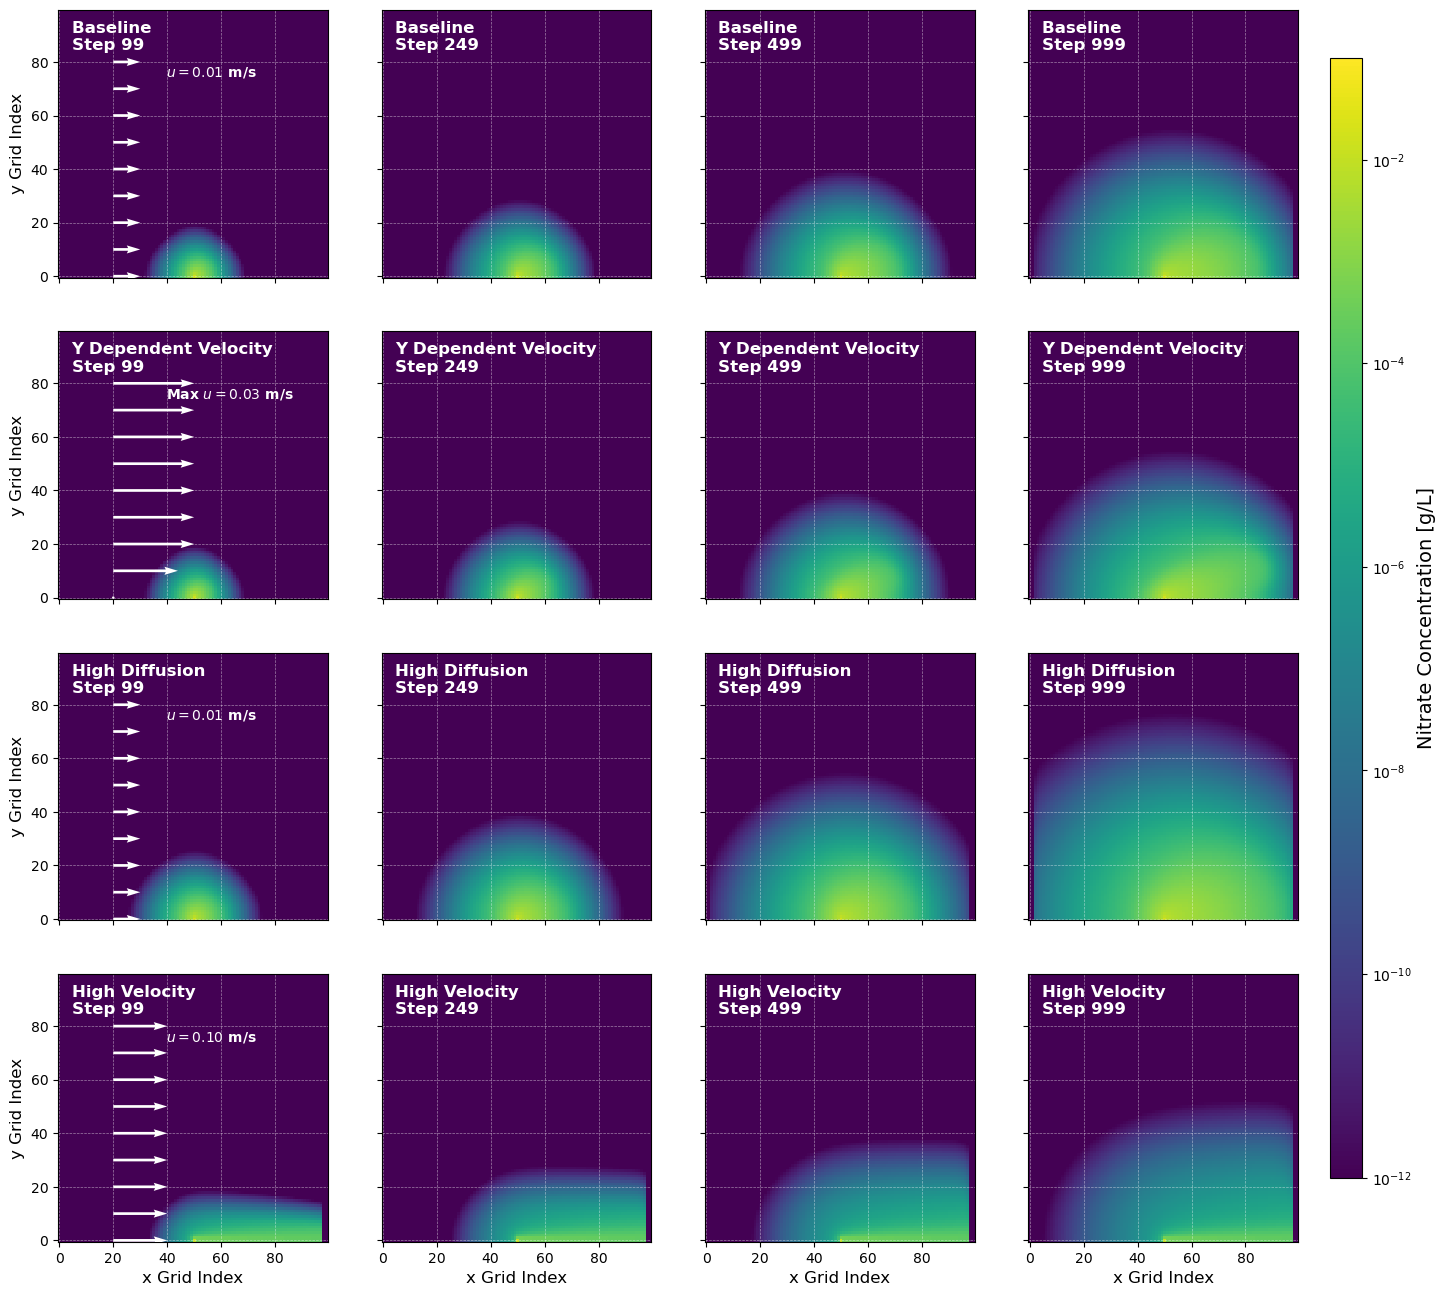

In [22]:
# Sensitivity Experiment Visualization

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cmx

c_baseline_aligned=c_baseline[:, 2:-2, :]
c_XDV_aligned=c_XDV[:, 2:-2, :]
c_HD_aligned=c_HD[:, 2:-2, :]
c_HU_aligned=c_HU[:, 2:-2, :]

# print(np.shape(c_baseline_aligned))

# Grids
x = np.arange(100)
y = np.arange(100)
X1, Y1 = np.meshgrid(x, y)


experiments = [c_baseline_aligned, c_XDV_aligned, c_HD_aligned, c_HU_aligned]
exp_labels = ['Baseline', 'Y Dependent Velocity', 'High Diffusion', 'High Velocity']
tt = [99, 249, 499, 999]

# Shared colorbar
# maxval = np.max([np.nanmax(exp) for exp in experiments])
# print(maxval)

cmap = cmx.viridis
norm = colors.LogNorm(vmin=1e-12, vmax=1e-1)

# Visualization
fig, axes = plt.subplots(4, 4, figsize=(16, 16), sharex=True, sharey=True)

# experiment loop
for i, exp_data in enumerate(experiments):
    # time step loop
    for j, t in enumerate(tt):
        ax = axes[i, j]
        
        
        cc = exp_data[t, :, :]
        cc = cc + 1e-13
        

        ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)
        
        # pcolormesh
        im = ax.pcolormesh(X1, Y1, cc.T, cmap=cmap, norm=norm, shading='nearest')
        
        # label
        label_full = f'{exp_labels[i]} \nStep {t}'
        ax.text(0.05, 0.85, label_full, transform=ax.transAxes, color='white', fontsize=12, fontweight='bold')

        if i == 3: 
            ax.set_xlabel('x Grid Index', fontsize=12)
        if j == 0: 
            ax.set_ylabel('y Grid Index', fontsize=12)
            
        # Quiver 
        if j == 0:
            X_arrow_position = 20
            Y_arrow = y[::10]
            # Y_arrow.pop() 
            Y_arrow=np.delete(Y_arrow,-1)
            X_arrow = np.zeros_like(Y_arrow) + X_arrow_position
    
            u0 = 0.01  # baseline
    
            U_speed = np.ones_like(Y_arrow) * u0
            V_speed = np.zeros_like(Y_arrow)
            speed_text_val = u0
            arrow_scale = 0.1

    
            speed_text_str = f'$u={speed_text_val:.2f}$ m/s'

    
            if exp_labels[i] == 'Y Dependent Velocity': 
                U_speed = u0 * np.log((Y_arrow+1) )
                U_speed[U_speed > 3 * u0] = 3 * u0
                speed_text_val = 3 * u0
                speed_text_str = f'Max $u={speed_text_val:.2f}$ m/s'
                arrow_scale = 0.1
                print('Y Dependent Velocity U_speed:', U_speed)
        
            elif exp_labels[i] == 'High Velocity':
                high_u_val = 0.1
                U_speed = np.ones_like(Y_arrow) * high_u_val
                speed_text_val = high_u_val
                speed_text_str = f'$u={speed_text_val:.2f}$ m/s'
                arrow_scale = 0.5
    
    
            ax.quiver(X_arrow, Y_arrow, U_speed, V_speed, color='white', scale=arrow_scale, width=0.01, zorder=3)
    
            ax.text(0.4, 0.75, speed_text_str, transform=ax.transAxes, color='white', fontsize=10, fontweight='bold')

# leave room for colorbar
fig.subplots_adjust(right=0.90)

cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label('Nitrate Concentration [g/L]', fontsize=14)

plt.show()

In [25]:
# Animation

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.animation as animation

c_baseline_aligned = c_baseline[:, 2:-2, :]
c_XDV_aligned = c_XDV[:, 2:-2, :]
c_HD_aligned = c_HD[:, 2:-2, :]
c_HU_aligned = c_HU[:, 2:-2, :]

x = np.arange(100)
y = np.arange(100)
X1, Y1 = np.meshgrid(x, y)

experiments = [c_baseline_aligned, c_XDV_aligned, c_HD_aligned, c_HU_aligned]
exp_labels = ['Baseline', 'Y Dependent Velocity', 'High Diffusion', 'High Velocity']
file_names = ['Baseline', 'Y_Dependent_Velocity', 'High_Diffusion', 'High_Velocity']


norm = colors.LogNorm(vmin=1e-12, vmax=1e-1)

time_series = range(0, 1000, 10)

def plot_renew(tt, exp_data, im, title_text, label_name):
    cc = exp_data[tt, :, :] + 1e-11
    im.set_array(cc.T.ravel())
    title_text.set_text(f'{label_name} \nStep {tt}')
    return im, title_text

for i, (exp_data, label_name, fname) in enumerate(zip(experiments, exp_labels, file_names)):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)

    t0 = time_series[0]
    cc0 = exp_data[t0, :, :] + 1e-13

    im = ax.pcolormesh(X1, Y1, cc0.T, cmap=cmap, norm=norm, shading='nearest')
    
    title_text = ax.text(0.05, 0.85, f'{label_name} Step {t0}', transform=ax.transAxes, color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel('x Grid Index', fontsize=12)
    ax.set_ylabel('y Grid Index', fontsize=12)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Nitrate Concentration [g/L]', fontsize=11)

    Y_arrow_position = 20
    X_arrow = x[::10]
    X_arrow=np.delete(X_arrow,-1)
    Y_arrow = np.zeros_like(X_arrow) + Y_arrow_position
    u0 = 0.01

    if label_name == 'Y Dependent Velocity':
        V_speed = u0 * np.log(X_arrow * dx)
        V_speed[V_speed > 3 * u0] = 3 * u0
        speed_text_str = f'Max $v={3 * u0:.2f}$ m/s'
        arrow_scale = 0.1
    elif label_name == 'High Velocity':
        high_u_val = 0.1
        V_speed = np.ones_like(X_arrow) * high_u_val
        speed_text_str = f'$v={high_u_val:.2f}$ m/s'
        arrow_scale = 0.5
    else:
        V_speed = np.ones_like(X_arrow) * u0
        speed_text_str = f'$v={u0:.2f}$ m/s'
        arrow_scale = 0.1

    U_speed = np.zeros_like(X_arrow)

    ax.quiver( Y_arrow,X_arrow,  V_speed,U_speed, color='white', scale=arrow_scale, width=0.01, zorder=3)
    ax.text(0.4, 0.75, speed_text_str, transform=ax.transAxes, color='white', fontsize=10, fontweight='bold')

    plt.tight_layout()

    ani = animation.FuncAnimation(
        fig, 
        plot_renew, 
        frames=time_series, 
        fargs=(exp_data, im, title_text, label_name),
        interval=50, 
        blit=True
    )
    
    ani.save(f'{fname}_animation.gif', writer='pillow', fps=20)
    plt.close(fig)

/var/folders/w4/xp7bdxl93xxc0bljj6p5fw1m0000gn/T/ipykernel_62454/1817771181.py:56: RuntimeWarning: divide by zero encountered in log
  V_speed = u0 * np.log(X_arrow * dx)


In [1]:
# Initial Release Experiment

# Import

import context
from IPython.display import Image
import IPython.display as display
# import plotting package and numerical python package for use in examples later
import matplotlib.pyplot as plt
# import the numpy array handling library
import numpy as np
import importlib
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.colorbar as colorbar
# import the PDE solver for 2D advection-diffusion problem
import adv_dif_2D_bott
import adv_dif_2D_bott_Nflux
import adv_dif_2D_bott_Nflux_High_D
import adv_dif_2D_bott_Nflux_High_u

# set parameters
Lx=50
Ly=50
T=1000
n_x = 100
n_y = 100
n_time = 1000
dx = Lx / (n_x-1)
dy = Ly / (n_y-1)
dt = T / (n_time-1)
x = np.linspace(0,Lx,n_x)
y = np.linspace(0,Ly,n_y)
t = np.linspace(0,T,n_time)
U = 0 # 0 for constant wind / 1 for y-dependent wind 
N_flux = 0.01 # only for adv_dif_2D_Nflux (default=0.01 per time)

******************************
context imported. Front of path:
/Users/qiujunqi/Desktop/文件/课程/25秋冬/EOSC 511
back of path: /Users/qiujunqi/MOAD/tools/SalishSeaTools
******************************

through /Users/qiujunqi/Desktop/文件/课程/25秋冬/EOSC 511/EOSC511-TheDeepThinkers/2D visulization/context.py


In [2]:
# Run Initial Release

c_initial=adv_dif_2D_bott.adv_dif_2D([n_x, n_y, n_time, Lx, Ly, T, U, N_flux])

In [ ]:
# Animation

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cmx
import matplotlib.animation as animation

c_initial_aligned = c_initial[:, 2:-2, :]


x = np.arange(100)
y = np.arange(100)
X1, Y1 = np.meshgrid(x, y)

experiments = [c_initial_aligned]
exp_labels = ['Initial Release']
file_names = ['Initial_Release']


norm = colors.LogNorm(vmin=1e-12, vmax=1e-1)

time_series = range(0, 1000, 10)

def plot_renew(tt, exp_data, im, title_text, label_name):
    cc = exp_data[tt, :, :] + 1e-11
    im.set_array(cc.T.ravel())
    title_text.set_text(f'{label_name} \nStep {tt}')
    return im, title_text

for i, (exp_data, label_name, fname) in enumerate(zip(experiments, exp_labels, file_names)):
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    ax.grid(True, color='white', linestyle='--', linewidth=0.5, alpha=0.5, zorder=2)

    t0 = time_series[0]
    cc0 = exp_data[t0, :, :] + 1e-13

    im = ax.pcolormesh(X1, Y1, cc0.T, cmap=cmap, norm=norm, shading='nearest')
    
    title_text = ax.text(0.05, 0.85, f'{label_name} Step {t0}', transform=ax.transAxes, color='white', fontsize=12, fontweight='bold')
    ax.set_xlabel('x Grid Index', fontsize=12)
    ax.set_ylabel('y Grid Index', fontsize=12)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('Nitrate Concentration [g/L]', fontsize=11)

    Y_arrow_position = 20
    X_arrow = x[::10]
    X_arrow=np.delete(X_arrow,-1)
    Y_arrow = np.zeros_like(X_arrow) + Y_arrow_position
    u0 = 0.01

    
    V_speed = np.ones_like(X_arrow) * u0
    speed_text_str = f'$v={u0:.2f}$ m/s'
    arrow_scale = 0.1

    U_speed = np.zeros_like(X_arrow)

    ax.quiver( Y_arrow,X_arrow,  V_speed,U_speed, color='white', scale=arrow_scale, width=0.01, zorder=3)
    ax.text(0.4, 0.75, speed_text_str, transform=ax.transAxes, color='white', fontsize=10, fontweight='bold')

    plt.tight_layout()

    ani = animation.FuncAnimation(
        fig, 
        plot_renew, 
        frames=time_series, 
        fargs=(exp_data, im, title_text, label_name),
        interval=50, 
        blit=True
    )
    
    ani.save(f'{fname}_animation.gif', writer='pillow', fps=20)
    plt.close(fig)